In [1]:
!pip install datasets

In [5]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

import seaborn as sns

In [15]:
# Load the DAIR.AI Emotion dataset directly from Hugging Face.

from datasets import load_dataset
dataset = load_dataset("dair-ai/emotion")

In [16]:
## Convert the datasets into Dataframes
train_df = pd.DataFrame(dataset["train"])
val_df = pd.DataFrame(dataset["validation"])
test_df = pd.DataFrame(dataset["test"])

print("Training data:", train_df.shape)
print("Validation data:", val_df.shape)
print("Testing data:", test_df.shape)

Training data: (16000, 2)
Validation data: (2000, 2)
Testing data: (2000, 2)


In [17]:
#display sample data & Check Dataset Information
train_df.head()
print(train_df.info())
print("\nMissing values:")
print(train_df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16000 entries, 0 to 15999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    16000 non-null  object
 1   label   16000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 250.1+ KB
None

Missing values:
text     0
label    0
dtype: int64


In [18]:
#Analyze Emotion Class Distribution
label_names = [
    "sadness",
    "joy",
    "love",
    "anger",
    "fear",
    "surprise"
]

print(train_df["label"].value_counts().sort_index())

label
0    4666
1    5362
2    1304
3    2159
4    1937
5     572
Name: count, dtype: int64


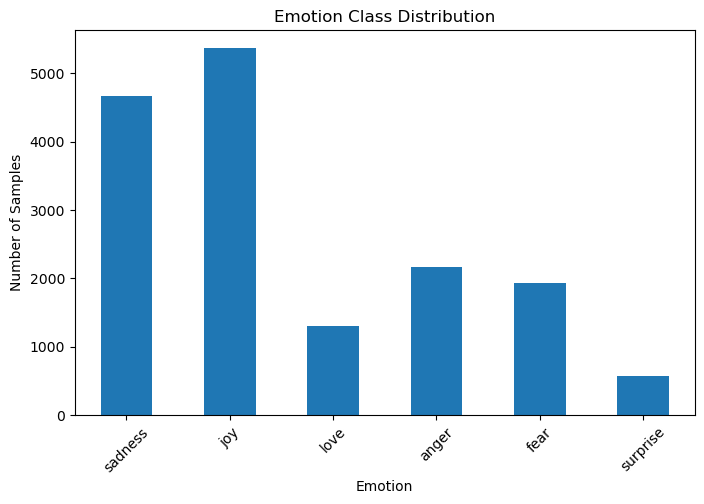

In [19]:
#visualize Emotion Class Distribution
plt.figure(figsize=(8,5))

train_df["label"].value_counts().sort_index().plot(kind="bar")

plt.xticks(
    range(6),
    label_names,
    rotation=45
)

plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.title("Emotion Class Distribution")

plt.show()

In [20]:
#Separate Input Text and Labels
X_train_text = train_df["text"].values
y_train = train_df["label"].values

X_val_text = val_df["text"].values
y_val = val_df["label"].values

X_test_text = test_df["text"].values
y_test = test_df["label"].values

In [21]:
#Tokenize the Text

max_words = 10000
max_length = 100

tokenizer = Tokenizer(
    num_words=max_words,
    oov_token="<OOV>"
)

tokenizer.fit_on_texts(X_train_text)

In [22]:
#Convert Text into Numerical Sequences
X_train = tokenizer.texts_to_sequences(X_train_text)
X_val = tokenizer.texts_to_sequences(X_val_text)
X_test = tokenizer.texts_to_sequences(X_test_text)

In [23]:
# Make all text sequences the same length by adding padding.
X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_val = pad_sequences(
    X_val,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

print("Training shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)


Training shape: (16000, 100)
Validation shape: (2000, 100)
Testing shape: (2000, 100)


In [24]:
# Build a Simple RNN model for classifying the input text
rnn_model = Sequential([
    Embedding(max_words, 64),
    SimpleRNN(64),
    Dropout(0.3),
    Dense(6, activation="softmax")
])

rnn_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
# Train the Simple RNN using the training dataset.
rnn_history = rnn_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)


Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step - accuracy: 0.3184 - loss: 1.6021 - val_accuracy: 0.3480 - val_loss: 1.5836
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3236 - loss: 1.5866 - val_accuracy: 0.3520 - val_loss: 1.5880
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.3296 - loss: 1.5832 - val_accuracy: 0.3520 - val_loss: 1.5834
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.3300 - loss: 1.5810 - val_accuracy: 0.3300 - val_loss: 1.6222
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.3306 - loss: 1.5816 - val_accuracy: 0.3520 - val_loss: 1.5829
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.3334 - loss: 1.5802 - val_accuracy: 0.3495 - val_loss: 1.5807
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.3340 - loss: 1.5788 - val_accuracy: 0.3520 - val_loss: 1.5838
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - accuracy: 0.3325 - loss: 1.5781 - val_acc

In [26]:
# Evaluate the trained RNN model on the unseen test dataset
rnn_loss, rnn_accuracy = rnn_model.evaluate(
    X_test,
    y_test
)
print("RNN Test Accuracy:", rnn_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.3400 - loss: 1.5619
RNN Test Accuracy: 0.3400000035762787


In [27]:
# Generate predictions for the test dataset using the trained RNN.

rnn_pred = rnn_model.predict(X_test)
rnn_pred_classes = np.argmax(rnn_pred, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step


In [28]:
# Calculate precision, recall, and F1-score to analyze the classification performance of the RNN.
rnn_precision = precision_score(
    y_test,
    rnn_pred_classes,
    average="weighted"
)
rnn_recall = recall_score(
    y_test,
    rnn_pred_classes,
    average="weighted"
)
rnn_f1 = f1_score(
    y_test,
    rnn_pred_classes,
    average="weighted"
)
print("RNN Results")
print("Accuracy :", rnn_accuracy)
print("Precision:", rnn_precision)
print("Recall   :", rnn_recall)
print("F1 Score :", rnn_f1)

RNN Results
Accuracy : 0.3400000035762787
Precision: 0.20765382319173364
Recall   : 0.34
F1 Score : 0.23316832928158268


C:\Users\Akshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [30]:
# Build an LSTM model for emotion classification.
lstm_model = Sequential([
    Embedding(max_words, 64),
    LSTM(64),
    Dropout(0.3),
    Dense(6, activation="softmax")
])

lstm_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

lstm_model.summary()


# Train the LSTM model using the training data
# and monitor its performance on the validation data.

lstm_history = lstm_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.3215 - loss: 1.5951 - val_accuracy: 0.3520 - val_loss: 1.5801
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.3274 - loss: 1.5830 - val_accuracy: 0.3520 - val_loss: 1.5810
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.3301 - loss: 1.5807 - val_accuracy: 0.3520 - val_loss: 1.5802
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.3316 - loss: 1.5794 - val_accuracy: 0.3520 - val_loss: 1.5856
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.3324 - loss: 1.5805 - val_accuracy: 0.3520 - val_loss: 1.5812
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.3331 - loss: 1.5798 - val_accuracy: 0.3520 - val_loss: 1.5838
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.3336 - loss: 1.5790 - val_accuracy: 0.3520 - val_loss: 1.5829
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.3331 - loss: 1.5787 - 

In [32]:
# Evaluate the trained LSTM model on the test dataset
# and calculate its test accuracy.
lstm_loss, lstm_accuracy = lstm_model.evaluate(
    X_test,
    y_test
)

print("LSTM Test Accuracy:", lstm_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3475 - loss: 1.5592
LSTM Test Accuracy: 0.3474999964237213


In [33]:
# Generate predictions using the trained LSTM model.
lstm_pred = lstm_model.predict(X_test)
lstm_pred_classes = np.argmax(lstm_pred, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step


In [34]:
# Calculate accuracy, precision, recall, and F1-score
lstm_precision = precision_score(
    y_test,
    lstm_pred_classes,
    average="weighted"
)

lstm_recall = recall_score(
    y_test,
    lstm_pred_classes,
    average="weighted"
)

lstm_f1 = f1_score(
    y_test,
    lstm_pred_classes,
    average="weighted"
)
print("LSTM Results")
print("Accuracy :", lstm_accuracy)
print("Precision:", lstm_precision)
print("Recall   :", lstm_recall)
print("F1 Score :", lstm_f1)

LSTM Results
Accuracy : 0.3474999964237213
Precision: 0.12075625
Recall   : 0.3475
F1 Score : 0.1792300556586271


C:\Users\Akshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [38]:
# Build a GRU model for emotion classification.
# GRU is a gated recurrent architecture that can capture sequence information with fewer gates than LSTM.
gru_model = Sequential([
    Embedding(max_words, 64),
    GRU(64),
    Dropout(0.3),
    Dense(6, activation="softmax")
])
gru_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)
gru_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_5 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [40]:
# Train the GRU model using the training dataset and validate it using the validation dataset.
gru_history = gru_model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)
# Evaluate the trained GRU model on the unseen test datasetand calculate its test accuracy.
gru_loss, gru_accuracy = gru_model.evaluate(
    X_test,
    y_test
)
print("GRU Test Accuracy:", gru_accuracy)

Epoch 1/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 19s 62ms/step - accuracy: 0.3258 - loss: 1.5932 - val_accuracy: 0.2750 - val_loss: 1.5912
Epoch 2/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.3251 - loss: 1.5836 - val_accuracy: 0.3520 - val_loss: 1.5816
Epoch 3/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 59ms/step - accuracy: 0.3291 - loss: 1.5819 - val_accuracy: 0.3520 - val_loss: 1.5817
Epoch 4/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.3319 - loss: 1.5816 - val_accuracy: 0.3520 - val_loss: 1.5811
Epoch 5/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.3298 - loss: 1.5801 - val_accuracy: 0.3520 - val_loss: 1.5810
Epoch 6/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.3323 - loss: 1.5796 - val_accuracy: 0.3520 - val_loss: 1.5822
Epoch 7/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.3325 - loss: 1.5788 - val_accuracy: 0.3520 - val_loss: 1.5809
Epoch 8/10
250/250 ━━━━━━━━━━━━━━━━━━━━ 14s 57ms/step - accuracy: 0.3327 - loss: 1.5793 - 

In [41]:
# Generate predictions using the trained GRU model.
# The class with the highest probability is selected as the prediction.
gru_pred = gru_model.predict(X_test)
gru_pred_classes = np.argmax(gru_pred, axis=1)

63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step


In [44]:
# Calculate precision, recall, and F1-score
# to evaluate the classification performance of the GRU.

gru_precision = precision_score(
    y_test,
    gru_pred_classes,
    average="weighted"
)

gru_recall = recall_score(
    y_test,
    gru_pred_classes,
    average="weighted"
)

gru_f1 = f1_score(
    y_test,
    gru_pred_classes,
    average="weighted"
)

print("GRU Results")
print("----------------")
print("Accuracy :", gru_accuracy)
print("Precision:", gru_precision)
print("Recall   :", gru_recall)
print("F1 Score :", gru_f1)

GRU Results
----------------
Accuracy : 0.3474999964237213
Precision: 0.12075625
Recall   : 0.3475
F1 Score : 0.1792300556586271


C:\Users\Akshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [45]:
# Create a comparison table containing the main evaluation
# metrics of the RNN, LSTM, and GRU models.

results = pd.DataFrame({
    "Model": ["RNN", "LSTM", "GRU"],
    
    "Accuracy": [
        rnn_accuracy,
        lstm_accuracy,
        gru_accuracy
    ],
    
    "Precision": [
        rnn_precision,
        lstm_precision,
        gru_precision
    ],
    
    "Recall": [
        rnn_recall,
        lstm_recall,
        gru_recall
    ],
    
    "F1 Score": [
        rnn_f1,
        lstm_f1,
        gru_f1
    ]
})
results

,Model,Accuracy,Precision,Recall,F1 Score
0,RNN,0.3400,0.207654,0.3400,0.233168
1,LSTM,0.3475,0.120756,0.3475,0.179230
2,GRU,0.3475,0.120756,0.3475,0.179230


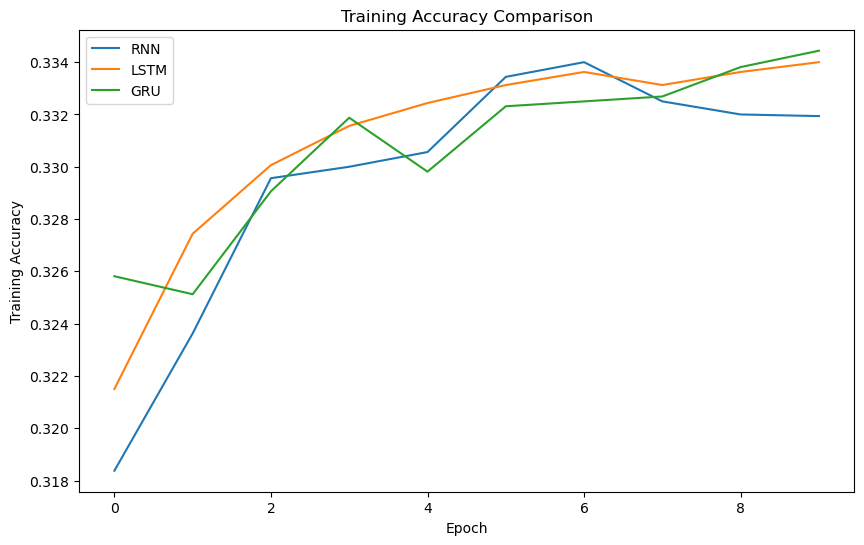

In [46]:
# Plot the training accuracy of all three modelsto observe how their performance changes across epochs.
plt.figure(figsize=(10,6))

plt.plot(
    rnn_history.history["accuracy"],
    label="RNN"
)

plt.plot(
    lstm_history.history["accuracy"],
    label="LSTM"
)

plt.plot(
    gru_history.history["accuracy"],
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")

plt.legend()
plt.show()

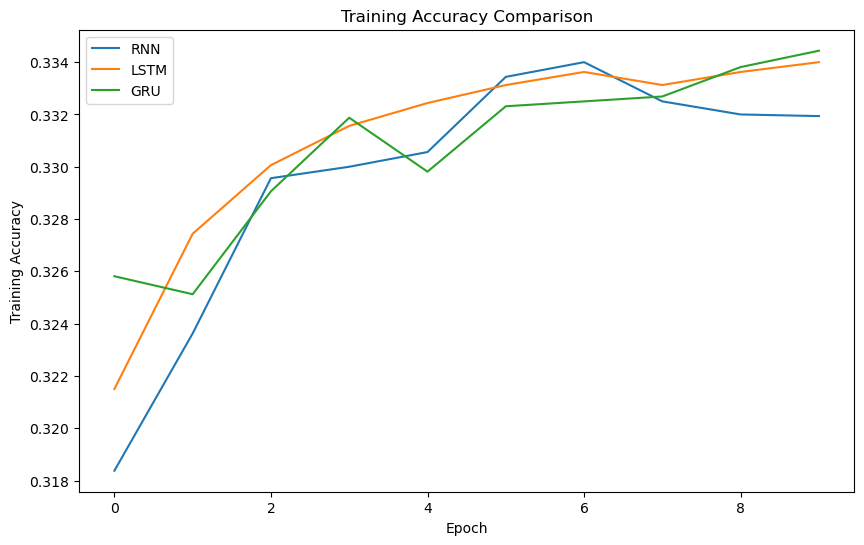

In [47]:
# Plot the training accuracy of all three models to observe how their performance changes across epochs.

plt.figure(figsize=(10,6))

plt.plot(
    rnn_history.history["accuracy"],
    label="RNN"
)

plt.plot(
    lstm_history.history["accuracy"],
    label="LSTM"
)

plt.plot(
    gru_history.history["accuracy"],
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy Comparison")

plt.legend()
plt.show()

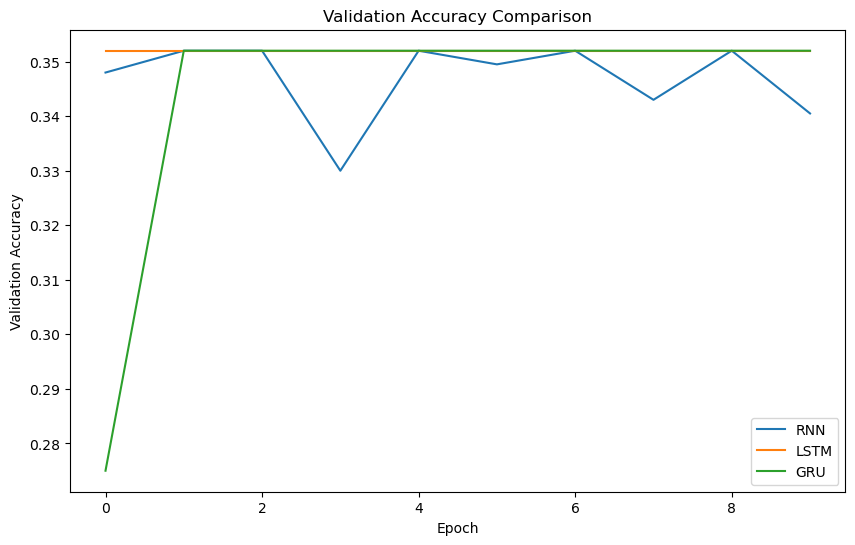

In [48]:
# Plot the validation accuracy of RNN, LSTM, and GRU to compare their performance on unseen validation data.

plt.figure(figsize=(10,6))

plt.plot(
    rnn_history.history["val_accuracy"],
    label="RNN"
)

plt.plot(
    lstm_history.history["val_accuracy"],
    label="LSTM"
)

plt.plot(
    gru_history.history["val_accuracy"],
    label="GRU"
)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy Comparison")

plt.legend()
plt.show()

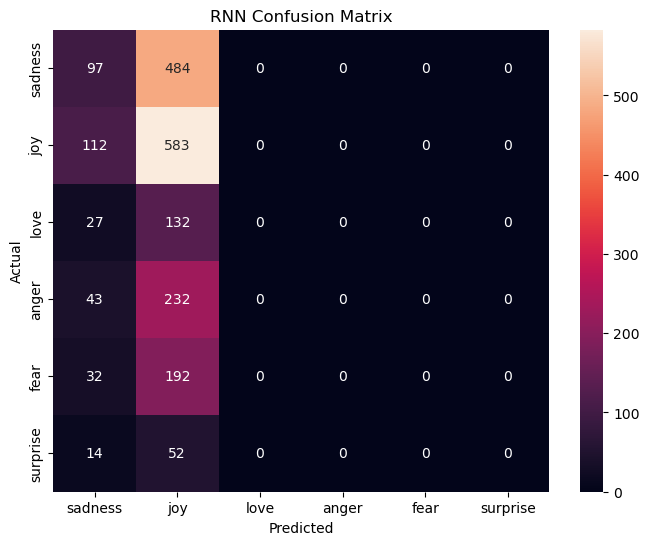

In [49]:
# Create a confusion matrix to analyze how the RNN classifies each of the six emotion categories.

cm = confusion_matrix(
    y_test,
    rnn_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("RNN Confusion Matrix")

plt.show()

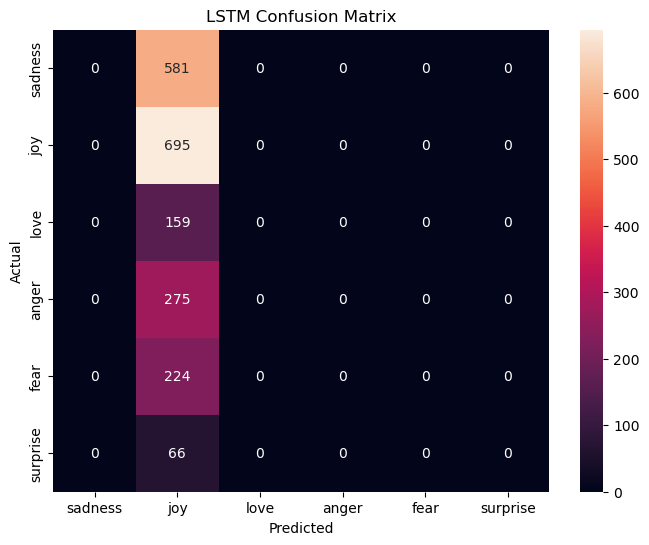

In [50]:
# Create a confusion matrix to analyze the classification performance of the LSTM for each emotion category.
cm = confusion_matrix(
    y_test,
    lstm_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("LSTM Confusion Matrix")

plt.show()

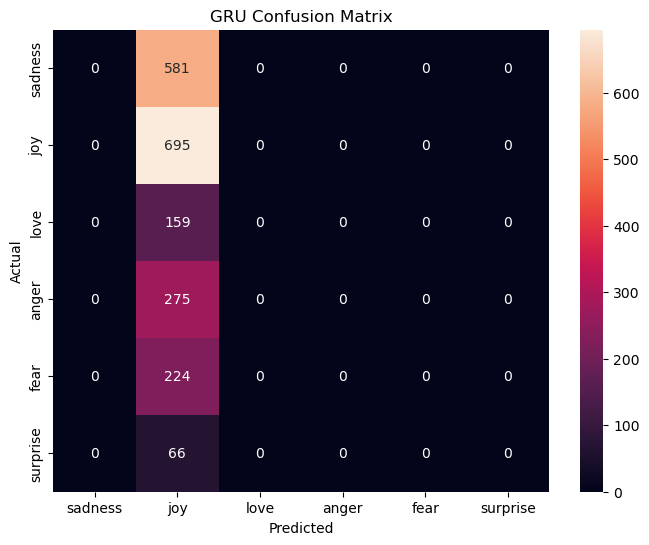

In [51]:
# Create a confusion matrix to analyze the classification performance of the GRU for each emotion category.

cm = confusion_matrix(
    y_test,
    gru_pred_classes
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=label_names,
    yticklabels=label_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("GRU Confusion Matrix")

plt.show()

In [52]:
# Generate detailed classification reports for all three models.
# The report contains precision, recall, F1-score, and support for each individual emotion class.

print("RNN Classification Report")
print(
    classification_report(
        y_test,
        rnn_pred_classes,
        target_names=label_names
    )
)

print("\nLSTM Classification Report")
print(
    classification_report(
        y_test,
        lstm_pred_classes,
        target_names=label_names
    )
)

print("\nGRU Classification Report")
print(
    classification_report(
        y_test,
        gru_pred_classes,
        target_names=label_names
    )
)

RNN Classification Report
              precision    recall  f1-score   support

     sadness       0.30      0.17      0.21       581
         joy       0.35      0.84      0.49       695
        love       0.00      0.00      0.00       159
       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.34      2000
   macro avg       0.11      0.17      0.12      2000
weighted avg       0.21      0.34      0.23      2000


LSTM Classification Report
              precision    recall  f1-score   support

     sadness       0.00      0.00      0.00       581
         joy       0.35      1.00      0.52       695
        love       0.00      0.00      0.00       159
       anger       0.00      0.00      0.00       275
        fear       0.00      0.00      0.00       224
    surprise       0.00      0.00      0.00        66

    accuracy           

C:\Users\Akshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akshada\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Akshada\anaco

In [53]:
# Define a function that takes a new sentence as input,preprocesses it using the same tokenizer and padding, and predicts its emotion using all three models.

def predict_emotion(text):

    sequence = tokenizer.texts_to_sequences([text])

    padded = pad_sequences(
        sequence,
        maxlen=max_length,
        padding="post",
        truncating="post"
    )

    rnn_prediction = np.argmax(
        rnn_model.predict(padded, verbose=0),
        axis=1
    )[0]

    lstm_prediction = np.argmax(
        lstm_model.predict(padded, verbose=0),
        axis=1
    )[0]

    gru_prediction = np.argmax(
        gru_model.predict(padded, verbose=0),
        axis=1
    )[0]

    print("\nRNN  :", label_names[rnn_prediction])
    print("LSTM :", label_names[lstm_prediction])
    print("GRU  :", label_names[gru_prediction])

In [57]:
# Take a sentence from the user and classify its emotion using the trained RNN, LSTM, and GRU models.

text = input("Enter a sentence: ")

predict_emotion(text)

Enter a sentence:   I am pretty today



RNN  : joy
LSTM : joy
GRU  : joy
